# Section 4 · Steering 与 prompt 的 attention 误差

每层一张双面板图，另附第 **3、9、18、27、34 层的平均图**。

- **左侧**：固定追加 prompt 长度 $m=4$；蓝色为 input-only steering，橙色为 4 个 input + generated positions。实线为 measured error，虚线为理论上界；两者共享纵轴。
- **右侧**：固定 single-token steering，紫色展示追加 prompt 长度与 measured error。
- 误差为 **原始** $\|o_{\mathrm{steer}}-o_{\mathrm{prompt}}\|_2$，没有除以输出范数、维度或直径。它是线性 attention head 的输出差值，不是完整模型最终输出的差值。
- 阴影是输入之间的 **mean ± sample std**。左侧固定 95 条长输入，右侧全部 400 条。先在每个输入内平均 heads；五层平均版先平均 5×2 个 head 的标量误差，再跨输入统计。**不平均标准差，也不先平均向量再取范数。**
- 这是固定表示、128 步 continuation query 的诊断；391/400 条轨迹在该步之前出现 EOS，不能直接当作自然生成结论。

运行前执行 `uv sync --group dev`，在 notebook 编辑器中选择项目 `.venv/bin/python`。只读取已提交的汇总数据，不重新运行模型。PDF 保存到 `figs/`，屏幕预览使用 SVG，不生成 PNG。

In [1]:
from pathlib import Path
import importlib.util
import io
import json
import sys

from IPython.display import SVG, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts/plot_section4_long.py").exists())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
spec = importlib.util.spec_from_file_location("section4_plot", ROOT / "scripts/plot_section4_long.py")
plotter = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plotter)
summary = json.loads((ROOT / "results/section4_long_summary.json").read_text())
stats = summary["comparison"] + summary["layer_mean_comparison"]

## 可调整的样式

修改下面的颜色、字号或层列表，再运行绘图单元。布局和绘图函数集中在 `scripts/plot_section4_long.py` 的 `combined_figure`，命令行与 notebook 使用相同代码。横轴为 log₂ 间隔，纵轴为线性原始数值；保留完整标准差阴影，因此下缘可能低于零。

In [2]:
LAYERS = [3, 9, 18, 27, 34]  # one-based
plotter.COLORS.update(input="#2673B8", mixed="#D97721", prompt="#7B4FA3")
plotter.STYLE.update({"font.size": 10, "axes.titlesize": 11})


def draw_layer(layer):
    """Use -1 for the five-layer mean, otherwise a zero-based layer index."""
    fig = plotter.combined_figure(stats, layer)
    path = ROOT / "figs" / plotter.figure_name(layer)
    with plotter.tee_stdout(ROOT / "logs/section4_notebook.log"):
        fig.savefig(path, bbox_inches="tight")  # PDF first
        print(f"Saved {path.relative_to(ROOT)}", flush=True)
    svg = io.StringIO()
    fig.savefig(svg, format="svg", bbox_inches="tight")
    plotter.plt.close(fig)
    display(SVG(svg.getvalue()))

## 五层平均

各层等权；由于使用未归一化的 L₂ 误差，数值尺度较大的层会更影响平均曲线。理论上界也按相同方式平均。

Saved figs/section4_layer_mean_combined.pdf

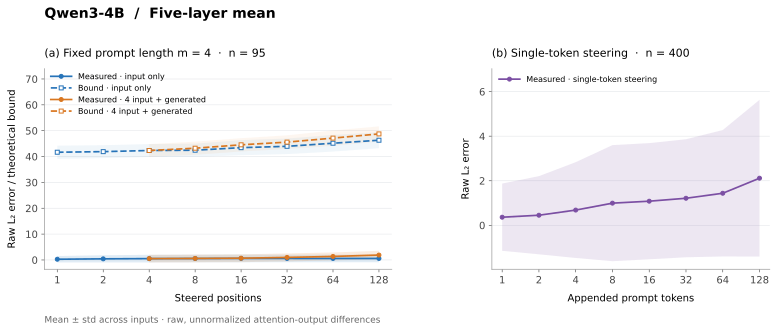

In [3]:
draw_layer(-1)

## 每层分别展示

Saved figs/section4_layer03_combined.pdf

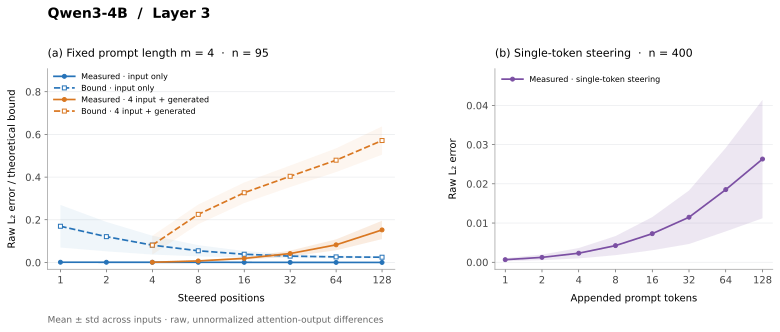

Saved figs/section4_layer09_combined.pdf

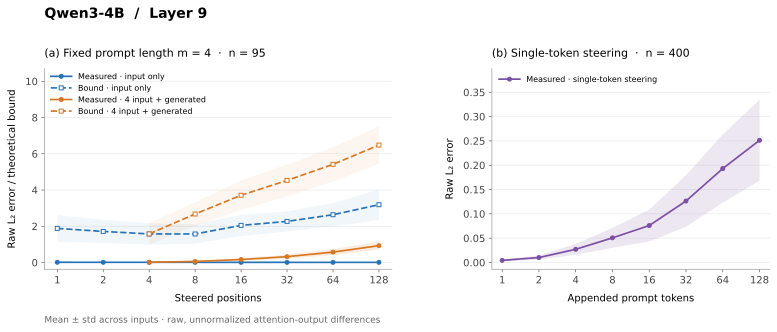

Saved figs/section4_layer18_combined.pdf

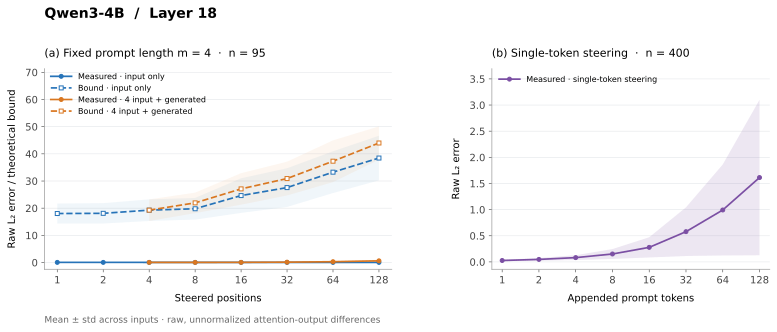

Saved figs/section4_layer27_combined.pdf

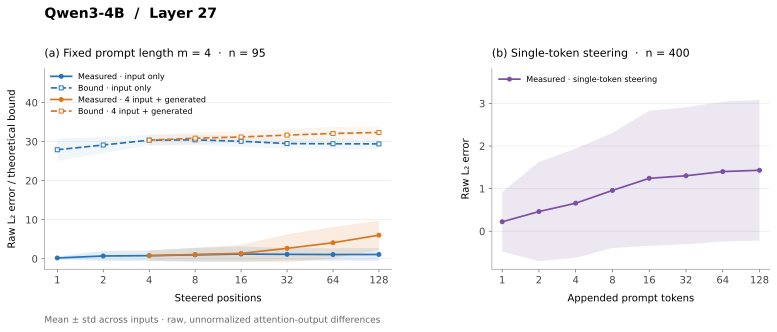

Saved figs/section4_layer34_combined.pdf

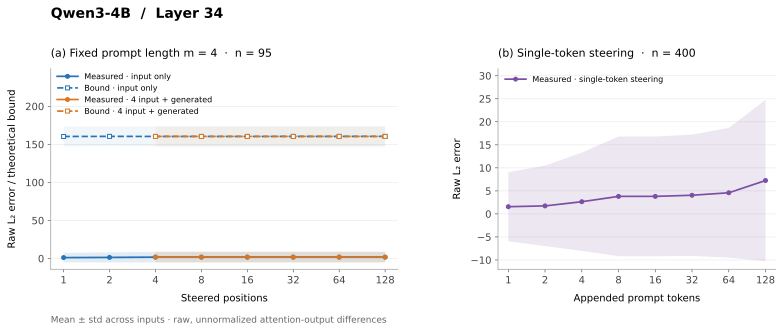

In [4]:
for layer in LAYERS:
    draw_layer(layer - 1)